In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv(r"C:\Users\LaptopWala\Downloads\iris.csv")
print(f"First five rows of the dataset:\n{df.head(5)}")
print(f"Shape of dataset is: {df.shape}")
print(f"Columns in the dataset: {list(df.columns)}")
print(f"Information about the dataset:\n{df.info()}")
print(f"Statistical summary of the dataset:\n{df.describe()}")
print(f"Number of missing values in each column:\n{df.isnull().sum()}")



First five rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape of dataset is: (150, 5)
Columns in the dataset: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

In [69]:
print(f"Duplicate rows in the dataset: {df.duplicated().sum()}")
print(f"check shape:\n{df.shape}")
print(f"Checking for duplicates:\n{df[df.duplicated()]}")
df = df.drop_duplicates()
print(f'After removing duplicates:\n{df.duplicated().sum()}')
print(f'check shape now:\n{df.shape}')

Duplicate rows in the dataset: 3
check shape:
(150, 5)
Checking for duplicates:
     sepal_length  sepal_width  petal_length  petal_width    species
34            4.9          3.1           1.5          0.1     setosa
37            4.9          3.1           1.5          0.1     setosa
142           5.8          2.7           5.1          1.9  virginica
After removing duplicates:
0
check shape now:
(147, 5)


In [70]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
df.species.value_counts()


species
1    50
2    49
0    48
Name: count, dtype: int64

In [71]:
X = df.drop(columns=['species'], axis = 1)
y = df['species']

In [72]:
y.value_counts()

species
1    50
2    49
0    48
Name: count, dtype: int64

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size = 0.2, random_state= 42)

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [75]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(117, 4)
(30, 4)
(117,)
(30,)


In [76]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
y_pred = model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy is: ", accuracy)

Accuracy is:  0.9333333333333333


Confusion Matrix:
 [[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


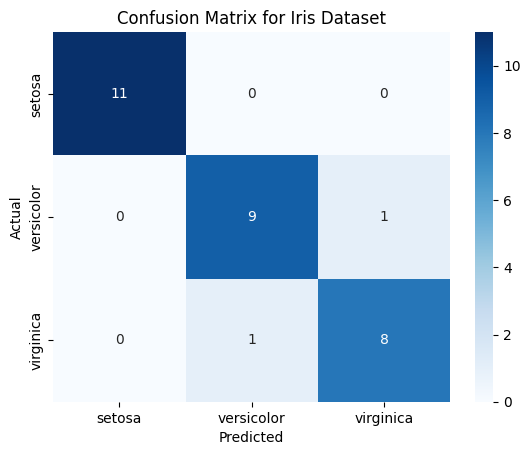


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [79]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(
    cm,
    annot=True,        
    fmt='d',           
    cmap='Blues',      
    xticklabels=le.classes_, 
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Iris Dataset")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [80]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Training Accuracy: {train_score:.2f}")
print(f"Testing Accuracy: {test_score:.2f}")

Training Accuracy: 0.98
Testing Accuracy: 0.93


In [ ]:
from sklearn.model_selection import GridSearchCV
parameter = [
    {'C': [0.01, 0.1, 0.5, 1, 1.5, 2],'penalty': ['l1'],'solver': ['liblinear']},
    {'C': [0.01, 0.1, 0.5, 1, 1.5, 2],'penalty': ['l2'],'solver': ['liblinear', 'lbfgs']},
    {'C': [0.01, 0.1, 0.5, 1, 1.5, 2],'penalty': ['elasticnet'],'solver': ['saga'], 'l1_ratio': [0.5, 0.7, 0.9]},
    
]
grid_search = GridSearchCV(estimator = LogisticRegression(max_iter=1000), param_grid= parameter,
                            scoring = 'accuracy', cv = 5, n_jobs= -1)
model = grid_search.fit(X_train, y_train)
print(f'Best parameters are:\n{grid_search.best_params_}')
print(f"best Accuracy is:\n{grid_search.best_score_}")

Best parameters are:
{'C': 1, 'l1_ratio': 0.9, 'penalty': 'elasticnet', 'solver': 'saga'}
best Accuracy is:
0.9916666666666668


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [92]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("Tuned Accuracy is: ", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy is:  0.9666666666666667


In [93]:
train_score = model.score(X_train,y_train)
test_score = model.score(X_test, y_test)

print(train_score)
print(test_score)

0.9914529914529915
0.9666666666666667


Confusion Matrix:
 [[11  0  0]
 [ 0  9  1]
 [ 0  0  9]]


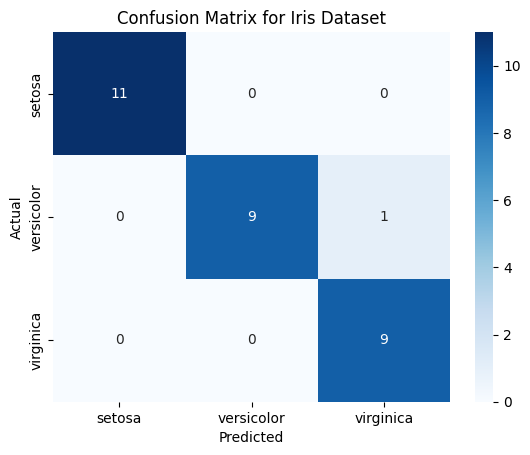


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.90      0.95        10
           2       0.90      1.00      0.95         9

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)
print("Confusion Matrix:\n", cm)

sns.heatmap(
    cm,
    annot=True,        
    fmt='d',           
    cmap='Blues',      
    xticklabels=le.classes_, 
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Iris Dataset")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))